In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Customer churn cleaned.xlsx")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,No
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,No
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Yes


In [3]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [15]:
df.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [17]:
churn_by_contract = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


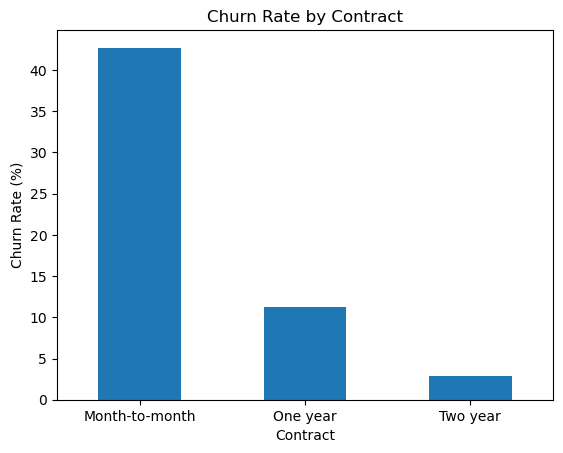

In [19]:
churn_by_contract['Yes'].plot(kind='bar')

plt.title('Churn Rate by Contract')
plt.xlabel('Contract')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [27]:
df.groupby('InternetService')['Churn'].value_counts()

InternetService  Churn
DSL              No       1962
                 Yes       459
Fiber optic      No       1799
                 Yes      1297
No               No       1413
                 Yes       113
Name: count, dtype: int64

In [29]:
churn_by_internet = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_internet

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


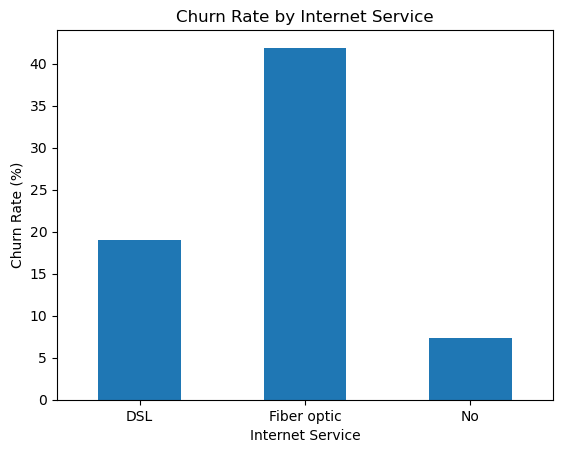

In [31]:
churn_by_internet['Yes'].plot(kind='bar')

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [33]:
df.groupby('PaymentMethod')['Churn'].value_counts()

PaymentMethod              Churn
Bank transfer (automatic)  No       1286
                           Yes       258
Credit card (automatic)    No       1290
                           Yes       232
Electronic check           No       1294
                           Yes      1071
Mailed check               No       1304
                           Yes       308
Name: count, dtype: int64

In [35]:
churn_by_payment = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_payment

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


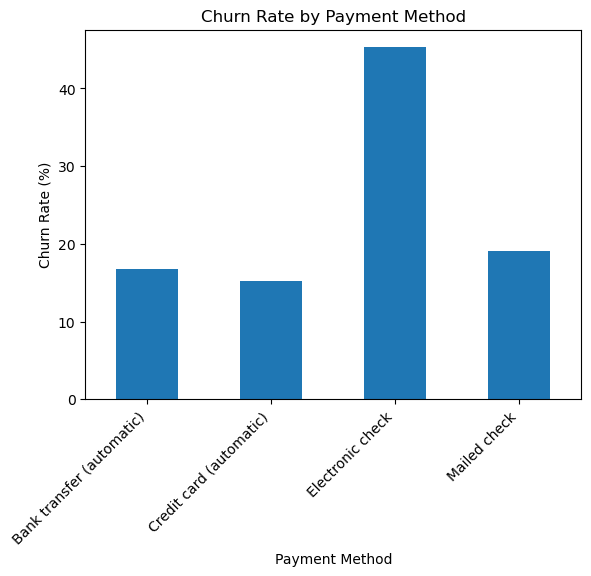

In [37]:
churn_by_payment['Yes'].plot(kind='bar')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [39]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 Months', '13-24 Months', '25-48 Months', '49-72 Months']
)

df[['tenure', 'TenureGroup']].head()

,tenure,TenureGroup
0,9,0-12 Months
1,9,0-12 Months
2,4,0-12 Months
3,13,13-24 Months
4,3,0-12 Months


In [41]:
churn_by_tenure = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_tenure

Churn,No,Yes
TenureGroup,,
0-12 Months,52.561757,47.438243
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


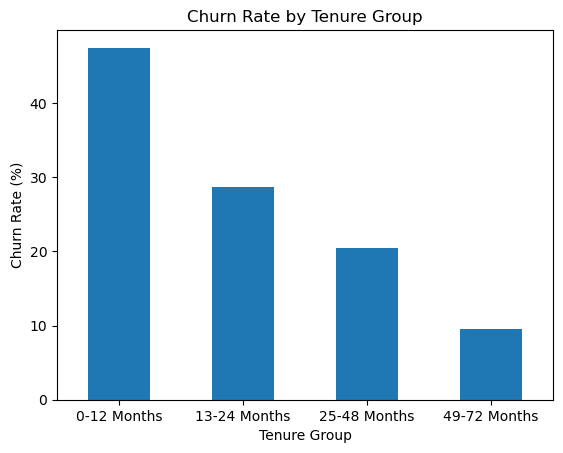

In [43]:
churn_by_tenure['Yes'].plot(kind='bar')

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [45]:
id="avg_charge_churn"
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [47]:
id="charge_group"
df['MonthlyChargesGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 40, 70, 100, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

df[['MonthlyCharges', 'MonthlyChargesGroup']].head()

,MonthlyCharges,MonthlyChargesGroup
0,65.6,Medium
1,59.9,Medium
2,73.9,High
3,98.0,High
4,83.9,High


In [49]:
churn_by_charges = pd.crosstab(
    df['MonthlyChargesGroup'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_charges

Churn,No,Yes
MonthlyChargesGroup,,
Low,88.356910,11.643090
Medium,76.078915,23.921085
High,62.178292,37.821708
Very High,71.951220,28.048780


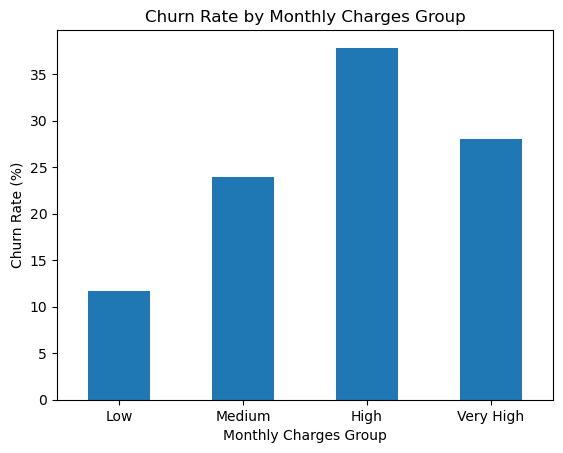

In [51]:
churn_by_charges['Yes'].plot(kind='bar')

plt.title('Churn Rate by Monthly Charges Group')
plt.xlabel('Monthly Charges Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [53]:
churn_by_tech = pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_tech

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


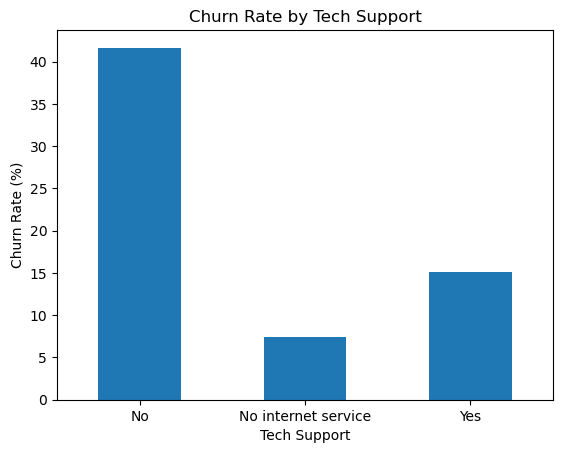

In [55]:
churn_by_tech['Yes'].plot(kind='bar')

plt.title('Churn Rate by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [57]:
churn_by_senior = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_senior

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


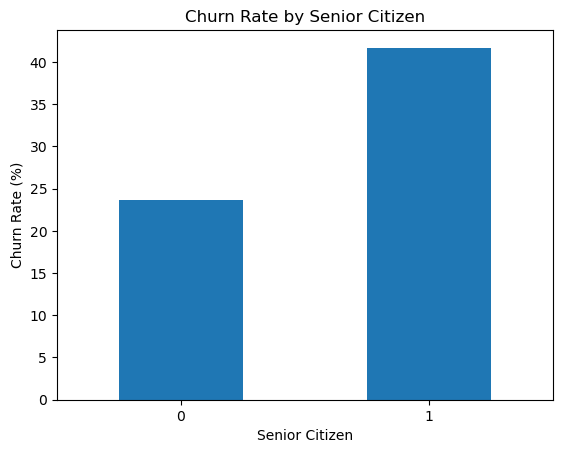

In [59]:
churn_by_senior['Yes'].plot(kind='bar')

plt.title('Churn Rate by Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [61]:
churn_by_dependents = pd.crosstab(
    df['Dependents'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_dependents

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


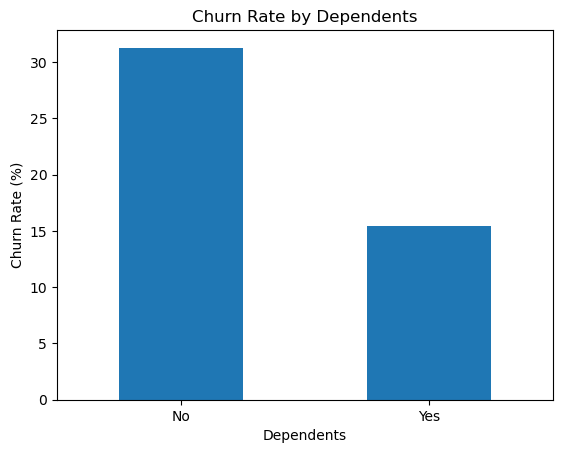

In [63]:
churn_by_dependents['Yes'].plot(kind='bar')

plt.title('Churn Rate by Dependents')
plt.xlabel('Dependents')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [66]:
churn_by_partner = pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

churn_by_partner

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


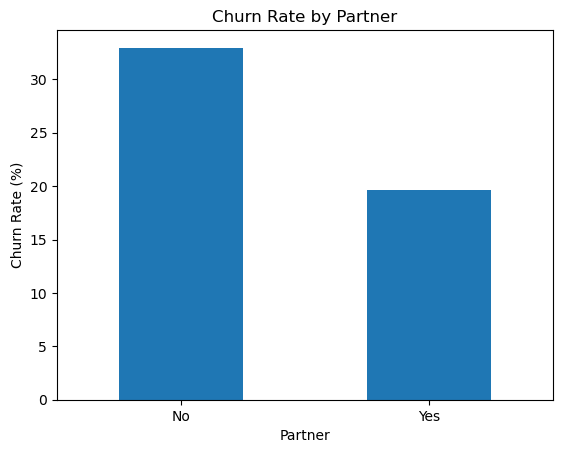

In [68]:
churn_by_partner['Yes'].plot(kind='bar')

plt.title('Churn Rate by Partner')
plt.xlabel('Partner')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [70]:
churn_by_contract_payment = pd.crosstab(
    [df['Contract'], df['PaymentMethod']],
    df['Churn'],
    normalize='index'
) * 100

churn_by_contract_payment

Churn                                            No        Yes
Contract       PaymentMethod                                  
Month-to-month Bank transfer (automatic)  65.874363  34.125637
               Credit card (automatic)    67.219153  32.780847
               Electronic check           46.270270  53.729730
               Mailed check               68.421053  31.578947
One year       Bank transfer (automatic)  90.281330   9.718670
               Credit card (automatic)    89.698492  10.301508
               Electronic check           81.556196  18.443804
               Mailed check               93.175074   6.824926
Two year       Bank transfer (automatic)  96.631206   3.368794
               Credit card (automatic)    97.762478   2.237522
               Electronic check           92.261905   7.738095
               Mailed check               99.214660   0.785340

In [72]:
segment_analysis = pd.DataFrame({
    'Segment': [
        'Month-to-month Contract',
        'Fiber Optic Internet',
        'Electronic Check',
        '0-12 Months Tenure',
        'High Monthly Charges',
        'No Tech Support',
        'Senior Citizen',
        'No Dependents',
        'No Partner'
    ],
    'Churn Rate (%)': [
        42.71,
        41.89,
        45.29,
        47.44,
        37.82,
        41.64,
        41.68,
        31.28,
        32.96
    ]
})

segment_analysis

,Segment,Churn Rate (%)
0,Month-to-month Contract,42.71
1,Fiber Optic Internet,41.89
2,Electronic Check,45.29
3,0-12 Months Tenure,47.44
4,High Monthly Charges,37.82
5,No Tech Support,41.64
6,Senior Citizen,41.68
7,No Dependents,31.28
8,No Partner,32.96
